# Preparação dos dados de overhead de ofuscação (Allatori)

Aplicada aos dados **reais** produzidos pelo pipeline deste repositório (`analysis/summary.csv` e `analysis/arch_interaction.csv`),
gerados por `scripts/07_analyze.py` a partir dos resultados de benchmark JMH (overhead de tempo de execução introduzido por cada perfil de ofuscação Allatori,
em x86_64 e aarch64).
<hr>

### 1. Bibliotecas utilizadas

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)


### 2. Leitura dos dados

Duas tabelas são produzidas pelo estágio T8 (`scripts/07_analyze.py`):

- `analysis/summary.csv`: tempo médio (com IC 95%) e overhead percentual de cada
  perfil de ofuscação (`baseline`, `flow`, `string`, `flowstring`) em relação ao
  `original`, por arquitetura (`x86_64`, `aarch64`) e tamanho de carga (`size`),
  com o teste estatístico (Welch-t ou Mann-Whitney), p-valor corrigido
  (Holm-Bonferroni) e tamanho de efeito (delta de Cliff).
- `analysis/arch_interaction.csv`: diferença de overhead entre as duas
  arquiteturas, para cada combinação de `size` e `profile`.

In [4]:
summary = pd.read_csv("analysis/summary.csv")
arch_interaction = pd.read_csv("analysis/arch_interaction.csv")

print("summary.csv:", summary.shape)
summary.head(10)


summary.csv: (30, 16)


,arch,size,profile,mean,ci_lo,ci_hi,unit,overhead_%_vs_original,overhead_ci_lo,overhead_ci_hi,test,p_value,cliffs_delta,n_forks,p_value_holm,significant_5%
0,aarch64,5000,baseline,1230.6997,1213.3711,1248.0283,us/op,-0.07,-1.58,1.48,welch-t,0.930695,-0.02,10,0.930695,False
1,aarch64,5000,flow,1217.0310,1203.3168,1230.7451,us/op,-1.18,-2.59,0.15,welch-t,0.126301,-0.34,10,0.252603,False
2,aarch64,5000,flowstring,1834.9413,1778.8414,1891.0412,us/op,48.99,45.13,53.25,welch-t,0.000000,1.00,10,0.000000,True
3,aarch64,5000,original,1231.6012,1216.3001,1246.9022,us/op,0.00,NaN,NaN,NaN,NaN,NaN,10,NaN,False
4,aarch64,5000,string,1837.8063,1786.7540,1888.8587,us/op,49.22,45.66,53.10,welch-t,0.000000,1.00,10,0.000000,True
5,aarch64,20000,baseline,5069.9282,4928.8107,5211.0456,us/op,0.84,-1.71,3.61,mann-whitney,0.850107,0.06,10,0.850107,False
6,aarch64,20000,flow,5080.8967,4979.9855,5181.8079,us/op,1.06,-1.01,3.24,mann-whitney,0.344704,0.26,10,0.689408,False
7,aarch64,20000,flowstring,7370.0563,7245.3827,7494.7300,us/op,46.60,43.73,49.40,mann-whitney,0.000183,1.00,10,0.000731,True
8,aarch64,20000,original,5027.4485,4944.7446,5110.1524,us/op,0.00,NaN,NaN,NaN,NaN,NaN,10,NaN,False
9,aarch64,20000,string,7333.2751,7211.5155,7455.0347,us/op,45.86,43.07,48.69,mann-whitney,0.000183,1.00,10,0.000731,True


In [5]:
print("arch_interaction.csv:", arch_interaction.shape)
arch_interaction.head(10)


arch_interaction.csv: (12, 12)


,size,profile,arch_a,arch_b,overhead_diff_%_(b_minus_a),diff_ci_lo,diff_ci_hi,p_value,n_forks_a,n_forks_b,p_value_holm,significant_arch_diff_5%
0,5000,baseline,aarch64,x86_64,4.37,2.22,6.52,0.0000,10,10,0.0000,True
1,5000,flow,aarch64,x86_64,7.56,5.57,9.63,0.0000,10,10,0.0000,True
2,5000,flowstring,aarch64,x86_64,50.42,45.40,55.14,0.0000,10,10,0.0000,True
3,5000,string,aarch64,x86_64,51.08,46.46,55.44,0.0000,10,10,0.0000,True
4,20000,baseline,aarch64,x86_64,0.55,-2.62,3.51,0.7038,10,10,0.7038,False
5,20000,flow,aarch64,x86_64,1.78,-0.63,4.08,0.1416,10,10,0.2832,False
6,20000,flowstring,aarch64,x86_64,32.31,29.12,35.53,0.0000,10,10,0.0000,True
7,20000,string,aarch64,x86_64,34.03,30.83,37.13,0.0000,10,10,0.0000,True
8,50000,baseline,aarch64,x86_64,1.96,0.64,3.28,0.0022,10,10,0.0044,True
9,50000,flow,aarch64,x86_64,1.68,0.38,2.97,0.0112,10,10,0.0112,True


### 3. Inspeção inicial

Assim como no notebook de referência, começamos verificando dimensão, tipos de
dado, valores ausentes e duplicatas antes de qualquer transformação.

In [6]:
print("Colunas de summary:")
print(summary.columns.tolist())

print("\nTipos de dado:")
print(summary.dtypes)

print("\nValores ausentes por coluna:")
print(summary.isna().sum())

print("\nNúmero de linhas duplicadas:", summary.duplicated().sum())


Colunas de summary:
['arch', 'size', 'profile', 'mean', 'ci_lo', 'ci_hi', 'unit', 'overhead_%_vs_original', 'overhead_ci_lo', 'overhead_ci_hi', 'test', 'p_value', 'cliffs_delta', 'n_forks', 'p_value_holm', 'significant_5%']

Tipos de dado:
arch                          str
size                        int64
profile                       str
mean                      float64
ci_lo                     float64
ci_hi                     float64
unit                          str
overhead_%_vs_original    float64
overhead_ci_lo            float64
overhead_ci_hi            float64
test                          str
p_value                   float64
cliffs_delta              float64
n_forks                     int64
p_value_holm              float64
significant_5%               bool
dtype: object

Valores ausentes por coluna:
arch                      0
size                      0
profile                   0
mean                      0
ci_lo                     0
ci_hi                     0
unit

### 4. Valores ausentes: um caso estrutural, não um erro

As colunas `overhead_ci_lo`, `overhead_ci_hi`, `test`, `p_value`, `cliffs_delta` 
e `p_value_holm` são `NaN` **apenas** nas linhas em que `profile == "original"` 
— porque a linha original é a própria referência de comparação, não faz sentido 
testá-la contra si mesma.

Por isso, a estratégia correta aqui **não é remover nem imputar** esses valores
(imputar um p-valor ou um delta de Cliff seria estatisticamente incorreto).
Em vez disso, tornamos essa condição explícita com uma coluna booleana.

In [7]:
colunas_com_nan = summary.columns[summary.isna().any()].tolist()
print("Colunas com valores ausentes:", colunas_com_nan)

linhas_nan = summary[summary[colunas_com_nan].isna().any(axis=1)]
print("\nPerfis associados às linhas com valores ausentes:")
print(linhas_nan["profile"].value_counts())

# Confirma que o padrão de ausência é 100% explicado por profile == "original".
assert set(linhas_nan["profile"].unique()) == {"original"}

summary["is_baseline"] = summary["profile"].eq("original")
print("\nLinhas marcadas como baseline (sem comparação estatística):", summary["is_baseline"].sum())


Colunas com valores ausentes: ['overhead_ci_lo', 'overhead_ci_hi', 'test', 'p_value', 'cliffs_delta', 'p_value_holm']

Perfis associados às linhas com valores ausentes:
profile
original    6
Name: count, dtype: int64

Linhas marcadas como baseline (sem comparação estatística): 6


### 5. Duplicatas

In [8]:
chave = ["arch", "size", "profile"]
duplicadas = summary.duplicated(subset=chave)
print("Linhas duplicadas em (arch, size, profile):", duplicadas.sum())

duplicadas_interacao = arch_interaction.duplicated(subset=["size", "profile", "arch_a", "arch_b"])
print("Linhas duplicadas em arch_interaction:", duplicadas_interacao.sum())


Linhas duplicadas em (arch, size, profile): 0
Linhas duplicadas em arch_interaction: 0


### 6. Variáveis categóricas

Três colunas de `summary` são categóricas: `arch`, `profile` e `test`.

- `arch` e `test` não têm ordem natural → candidatas a **one-hot encoding**.
- `profile` tem uma ordem natural de **intensidade de ofuscação**
  (`original` < `baseline` < `flow`/`string` < `flowstring`), então usamos uma
  **codificação ordinal** explícita em vez de `factorize`/one-hot, preservando
  essa semântica para análises de tendência (ex.: correlação com overhead).

In [9]:
ordem_perfis = ["original", "baseline", "flow", "string", "flowstring"]
mapeamento_perfil = {perfil: nivel for nivel, perfil in enumerate(ordem_perfis)}
print("Mapeamento ordinal de profile:", mapeamento_perfil)

summary["profile"] = pd.Categorical(summary["profile"], categories=ordem_perfis, ordered=True)
summary["profile_level"] = summary["profile"].map(mapeamento_perfil).astype(int)

summary["arch"] = summary["arch"].astype("category")
summary["test"] = summary["test"].astype("category")

summary[["arch", "profile", "profile_level", "test"]].head(10)


Mapeamento ordinal de profile: {'original': 0, 'baseline': 1, 'flow': 2, 'string': 3, 'flowstring': 4}


,arch,profile,profile_level,test
0,aarch64,baseline,1,welch-t
1,aarch64,flow,2,welch-t
2,aarch64,flowstring,4,welch-t
3,aarch64,original,0,NaN
4,aarch64,string,3,welch-t
5,aarch64,baseline,1,mann-whitney
6,aarch64,flow,2,mann-whitney
7,aarch64,flowstring,4,mann-whitney
8,aarch64,original,0,NaN
9,aarch64,string,3,mann-whitney


In [10]:
# One-hot encoding de arch (sem ordem natural).
summary_onehot = pd.get_dummies(summary, columns=["arch"], prefix="arch", drop_first=True)
summary_onehot[[c for c in summary_onehot.columns if c.startswith("arch_")]].head(10)


,arch_x86_64
0,False
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,False
9,False


### 7. Normalização e padronização

`mean` (tempo absoluto) não é comparável entre arquiteturas nem entre tamanhos
de carga (µs/op em CPUs e workloads diferentes — ver nota do `CLAUDE.md`:
"Compare relative overhead (%) across architectures, never absolute times").
Por isso normalizamos `overhead_%_vs_original`, que já é a métrica relativa
usada nas comparações do projeto, com min-max e padronização (z-score).

In [11]:
overhead = summary["overhead_%_vs_original"]

overhead_minmax = (overhead - overhead.min()) / (overhead.max() - overhead.min())
overhead_z = (overhead - overhead.mean()) / overhead.std()

summary["overhead_%_minmax"] = overhead_minmax
summary["overhead_%_zscore"] = overhead_z

summary[["arch", "size", "profile", "overhead_%_vs_original", "overhead_%_minmax", "overhead_%_zscore"]].sort_values(
    "overhead_%_vs_original", ascending=False
).head(10)


,arch,size,profile,overhead_%_vs_original,overhead_%_minmax,overhead_%_zscore
19,x86_64,5000,string,100.30,1.000000,2.086041
17,x86_64,5000,flowstring,99.41,0.991230,2.060629
24,x86_64,20000,string,79.90,0.798975,1.503571
22,x86_64,20000,flowstring,78.91,0.789220,1.475304
29,x86_64,50000,string,76.38,0.764289,1.403067
27,x86_64,50000,flowstring,75.38,0.754434,1.374514
4,aarch64,5000,string,49.22,0.496650,0.627583
2,aarch64,5000,flowstring,48.99,0.494383,0.621015
14,aarch64,50000,string,48.16,0.486204,0.597317
12,aarch64,50000,flowstring,47.59,0.480587,0.581042


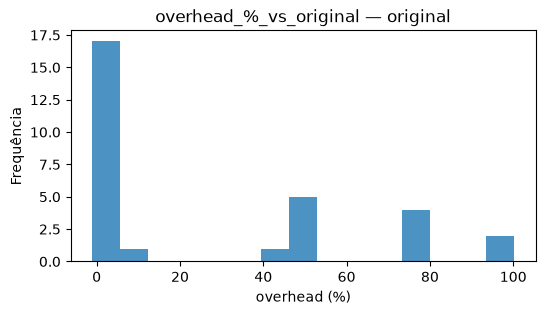

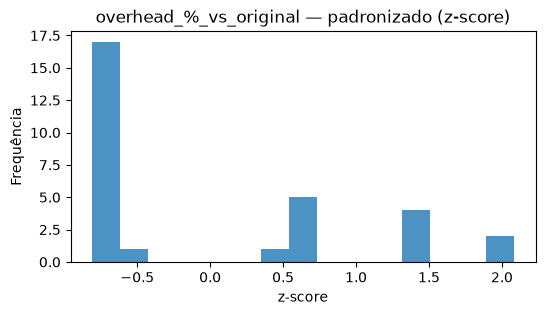

In [12]:
plt.figure(figsize=(6, 3))
plt.hist(overhead, bins=15, alpha=0.8)
plt.title("overhead_%_vs_original — original")
plt.xlabel("overhead (%)")
plt.ylabel("Frequência")
plt.show()

plt.figure(figsize=(6, 3))
plt.hist(overhead_z, bins=15, alpha=0.8)
plt.title("overhead_%_vs_original — padronizado (z-score)")
plt.xlabel("z-score")
plt.ylabel("Frequência")
plt.show()


### 8. Correlação entre variáveis numéricas

Analisamos a correlação entre `profile_level` (intensidade de ofuscação),
`size`, `mean`, `overhead_%_vs_original`, `p_value` e `cliffs_delta`, para
confirmar quantitativamente o que os gráficos `overhead-*.png` já sugerem:
overhead cresce com a intensidade de ofuscação (string/flowstring) e o efeito
é estatisticamente forte (delta de Cliff perto de 1) quando presente.

`n_forks` é excluída: é constante (10 em todas as linhas, por desenho do
benchmark — ver T6 no `CLAUDE.md`), então sua correlação com qualquer outra
variável é indefinida (desvio padrão zero).

n_forks é constante? True -> valor único: [10]


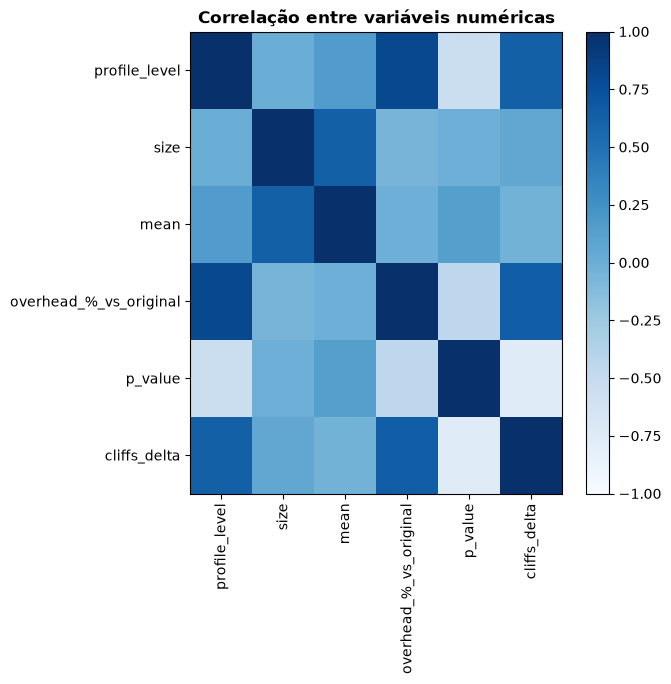

,profile_level,size,mean,overhead_%_vs_original,p_value,cliffs_delta
profile_level,1.000000e+00,-3.666738e-17,0.153266,0.811137,-0.556625,0.631726
size,-3.666738e-17,1.000000e+00,0.632402,-0.058110,-0.013706,0.056412
mean,1.532661e-01,6.324015e-01,1.000000,-0.015279,0.131040,-0.042835
overhead_%_vs_original,8.111370e-01,-5.810970e-02,-0.015279,1.000000,-0.452583,0.641997
p_value,-5.566246e-01,-1.370601e-02,0.131040,-0.452583,1.000000,-0.762580
cliffs_delta,6.317257e-01,5.641227e-02,-0.042835,0.641997,-0.762580,1.000000


In [13]:
print("n_forks é constante?", summary["n_forks"].nunique() == 1, "-> valor único:", summary["n_forks"].unique())

colunas_numericas = ["profile_level", "size", "mean", "overhead_%_vs_original", "p_value", "cliffs_delta"]
corr = summary[colunas_numericas].corr(numeric_only=True)

plt.figure(figsize=(6, 6))
plt.imshow(corr, cmap="Blues", interpolation="none", aspect="auto", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation="vertical")
plt.yticks(range(len(corr)), corr.columns)
plt.title("Correlação entre variáveis numéricas", fontsize=12, fontweight="bold")
plt.grid(False)
plt.show()

corr


### 9. Balanceamento dos grupos

O experimento é um fatorial completo (2 arquiteturas × 3 tamanhos × 5 perfis),
então não esperamos
desbalanceamento real. Ainda assim, verificamos explicitamente, pois qualquer
combinação faltante indicaria uma falha no pipeline (T6/T8) que precisaria ser
investigada antes de qualquer análise estatística.

In [14]:
print("Linhas por perfil:")
print(summary["profile"].value_counts().sort_index())

print("\nLinhas por arquitetura:")
print(summary["arch"].value_counts())

contagem = summary.groupby(["arch", "size"], observed=True).size()
print("\nLinhas por (arch, size) — deve ser 5 (uma por perfil) em todas as combinações:")
print(contagem)
assert (contagem == len(ordem_perfis)).all(), "Combinação (arch, size) com número de perfis inesperado"
print("\nFatorial completo confirmado: nenhuma combinação (arch, size, profile) ausente.")


Linhas por perfil:
profile
original      6
baseline      6
flow          6
string        6
flowstring    6
Name: count, dtype: int64

Linhas por arquitetura:
arch
aarch64    15
x86_64     15
Name: count, dtype: int64

Linhas por (arch, size) — deve ser 5 (uma por perfil) em todas as combinações:
arch     size 
aarch64  5000     5
         20000    5
         50000    5
x86_64   5000     5
         20000    5
         50000    5
dtype: int64

Fatorial completo confirmado: nenhuma combinação (arch, size, profile) ausente.


### 10. Preparação de `arch_interaction.csv`

Aplicamos a mesma limpeza — tipos, categorias ordenadas e checagem de
duplicatas/valores ausentes — à tabela de interação entre arquiteturas.

In [15]:
print("Valores ausentes por coluna:")
print(arch_interaction.isna().sum())

arch_interaction["profile"] = pd.Categorical(
    arch_interaction["profile"], categories=ordem_perfis, ordered=True
)
arch_interaction["arch_a"] = arch_interaction["arch_a"].astype("category")
arch_interaction["arch_b"] = arch_interaction["arch_b"].astype("category")

arch_interaction.head(12)


Valores ausentes por coluna:
size                           0
profile                        0
arch_a                         0
arch_b                         0
overhead_diff_%_(b_minus_a)    0
diff_ci_lo                     0
diff_ci_hi                     0
p_value                        0
n_forks_a                      0
n_forks_b                      0
p_value_holm                   0
significant_arch_diff_5%       0
dtype: int64


,size,profile,arch_a,arch_b,overhead_diff_%_(b_minus_a),diff_ci_lo,diff_ci_hi,p_value,n_forks_a,n_forks_b,p_value_holm,significant_arch_diff_5%
0,5000,baseline,aarch64,x86_64,4.37,2.22,6.52,0.0000,10,10,0.0000,True
1,5000,flow,aarch64,x86_64,7.56,5.57,9.63,0.0000,10,10,0.0000,True
2,5000,flowstring,aarch64,x86_64,50.42,45.40,55.14,0.0000,10,10,0.0000,True
3,5000,string,aarch64,x86_64,51.08,46.46,55.44,0.0000,10,10,0.0000,True
4,20000,baseline,aarch64,x86_64,0.55,-2.62,3.51,0.7038,10,10,0.7038,False
5,20000,flow,aarch64,x86_64,1.78,-0.63,4.08,0.1416,10,10,0.2832,False
6,20000,flowstring,aarch64,x86_64,32.31,29.12,35.53,0.0000,10,10,0.0000,True
7,20000,string,aarch64,x86_64,34.03,30.83,37.13,0.0000,10,10,0.0000,True
8,50000,baseline,aarch64,x86_64,1.96,0.64,3.28,0.0022,10,10,0.0044,True
9,50000,flow,aarch64,x86_64,1.68,0.38,2.97,0.0112,10,10,0.0112,True


### 11. Exportação dos dados preparados

Salvamos as versões preparadas (tipos corrigidos, coluna `is_baseline`,
`profile_level` ordinal e overhead normalizado) para uso em etapas seguintes
de análise/relatório, sem sobrescrever os arquivos originais produzidos pelo
pipeline (`analysis/summary.csv` continua sendo a saída oficial do T8).

In [16]:
summary_export = summary.drop(columns=["overhead_%_minmax", "overhead_%_zscore"])
summary_export.to_csv("analysis/summary_prepared.csv", index=False)
arch_interaction.to_csv("analysis/arch_interaction_prepared.csv", index=False)

print("Salvo: analysis/summary_prepared.csv", summary_export.shape)
print("Salvo: analysis/arch_interaction_prepared.csv", arch_interaction.shape)


Salvo: analysis/summary_prepared.csv (30, 18)
Salvo: analysis/arch_interaction_prepared.csv (12, 12)
